# GENERANDO CSV CONSOLIDADO 

In [ ]:
# Librerias Data Analisis

import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Creamos esta funcion para normalizar resources.csv y reservas.csv

def split_contained_metal(value):
    if pd.isna(value):
        return None, None
    
    match = re.match(r"([\d.,]+)\s*(.*)", str(value))
    if not match:
        return None, None
    
    number = float(match.group(1).replace(",", ""))
    unit = match.group(2).strip()
    return number, unit

In [12]:
# Cargamos la información ya recolectada por el RAG

metadata = pd.read_csv(r"output\metadata.csv")
resources = pd.read_csv(r"output\resources.csv")
reserves = pd.read_csv(r"output\reserves.csv")
economics = pd.read_csv(r"output\economics.csv")

In [9]:
# normalizamos resources.csv y reserves.csv
def normalizar(df):
    df[["contained_value", "contained_unit"]] = df["contained_metal"].apply(
        lambda x: pd.Series(split_contained_metal(x))
    )
    grouped = (
        df.groupby(["timestamp", "file_id", "category", "contained_unit"], as_index=False)
        .agg({
            "tonnage_mt": "sum",
            "grade_primary": "mean",
            "contained_value": "sum"
        })
    )
    grouped["contained_metal"] = (
        grouped["contained_value"].round(3).astype(str)
        + " "
        + grouped["contained_unit"]
    )

    return grouped.drop(columns=["contained_value", "contained_unit"])

In [10]:
resources = normalizar(resources)
reserves = normalizar(reserves)

In [14]:
# Funcion para aplanar resource y reserves

def wide(df):
    df_wide = (
        df
        .pivot_table(
            index=["timestamp", "file_id"],
            columns="category",
            values=["tonnage_mt", "grade_primary"],
            aggfunc="first"
        )
    )
    # Aplanar columnas
    df_wide.columns = [
        f"resources_{metric}_{category.lower()}"
        for metric, category in df_wide.columns
    ]

    return df_wide.reset_index()

In [15]:
resources_wide =  wide(resources)
reserves_wide =  wide(reserves)

## Unir todo en el CSV maestro

In [17]:
master_df = (
    metadata
    .merge(resources_wide, on=["timestamp", "file_id"], how="left")
    .merge(reserves_wide, on=["timestamp", "file_id"], how="left")
    .merge(economics, on=["timestamp", "file_id"], how="left")
)

In [ ]:
# guardamos una copia en formato csv, en output aunque puede ser json o cualquier otro

master_df.to_csv(r"output\master_dataset.csv", index=False)
print("✅ CSV maestro generado: master_dataset.csv")

# tambien se podria eliminar duplicados pero por motivo de la pruebas se decidio dejarlos

✅ CSV maestro generado: master_dataset.csv


## Resultados por expediente modelo Pydantic - LLamaIndex - Estructured

In [40]:
df = master_df.copy()
total_fields = df.shape[1] - 2

# Campos no nulos por fila (excluye timestamp y file_id)
df["non_null_fields"] = df.notnull().sum(axis=1) - 2

# Porcentaje de completitud
df["completeness_pct"] = (df["non_null_fields"] / total_fields) * 100

summary = (
    df.groupby("file_id")["completeness_pct"]
      .mean()
      .reset_index()
      .sort_values("completeness_pct", ascending=False)
)
print(summary.round(2))

    file_id  completeness_pct
1  2B2256D4             89.47
2  878C2FBC             84.21
0  278C5D9A             57.89
4  D11891E2             47.37
3  C03783C6             26.32


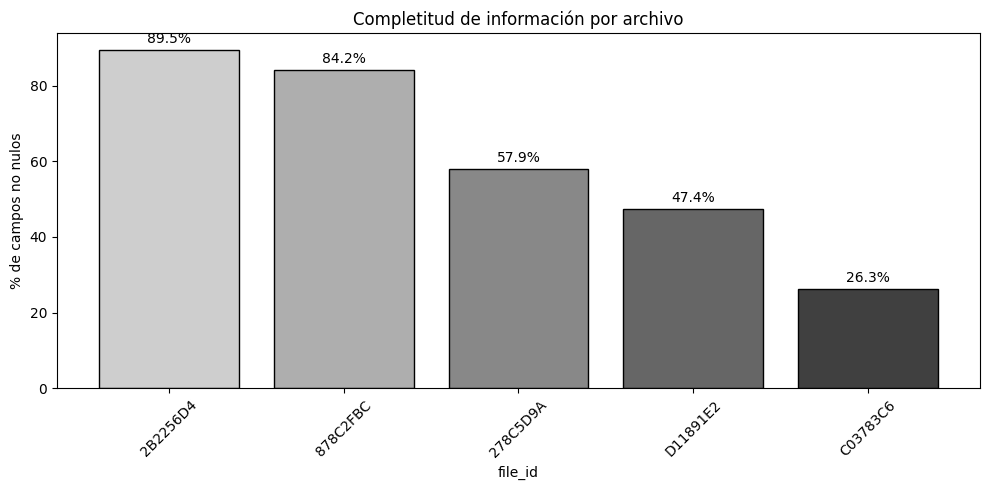

In [ ]:
# grafico de barras por expediente

colors = plt.cm.Greys(np.linspace(0.3, 0.8, len(summary)))
plt.figure(figsize=(10, 5))
bars=plt.bar(summary["file_id"], summary["completeness_pct"], color=colors, edgecolor="black")
plt.xlabel("file_id")
plt.ylabel("% de campos no nulos")
plt.title("Completitud de información por archivo")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Resultados por sección

In [34]:
sections = {
    "metadata": metadata,
    "resources": resources_wide,
    "reserves": reserves_wide,
    "economics": economics,
}
results = []

for section, df_section in sections.items():
    # columnas reales de la sección (excluyendo timestamp y file_id)
    section_cols = df_section.columns[2:]

    # tomar solo esas columnas desde el master
    existing_cols = [c for c in section_cols if c in master_df.columns]
    df_subset = master_df[existing_cols]

    total_fields = df_subset.shape[0] * df_subset.shape[1]
    non_null_fields = df_subset.notnull().sum().sum()

    completeness_pct = (non_null_fields / total_fields) * 100 if total_fields > 0 else 0

    results.append({
        "section": section,
        "completeness_pct": completeness_pct
    })

summary = pd.DataFrame(results)


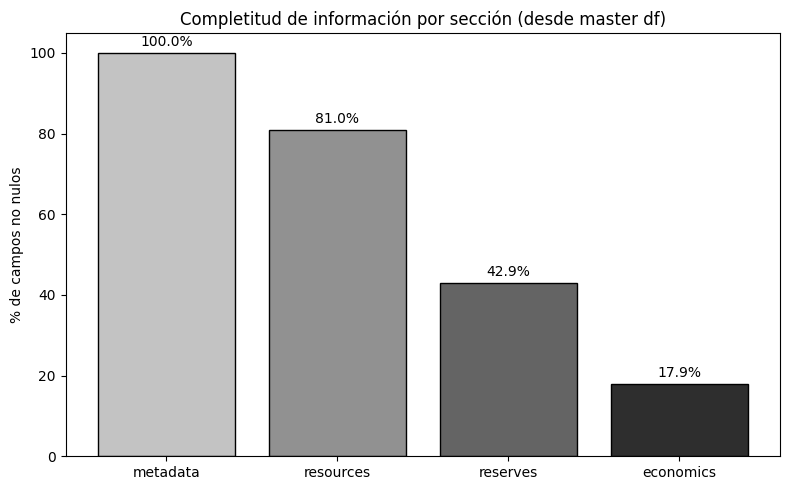

In [ ]:
# grafico de barras por secciones 

colors = plt.cm.Greys(np.linspace(0.35, 0.85, len(summary)))

plt.figure(figsize=(8, 5))
bars = plt.bar(
    summary["section"],
    summary["completeness_pct"],
    color=colors,
    edgecolor="black"
)

plt.ylabel("% de campos no nulos")
plt.title("Completitud de información por sección (desde master df)")
plt.ylim(0, 105)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()